<a href="https://colab.research.google.com/github/Neoseb92/Modulo-1-AI/blob/main/Jesus_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression RMSE: 53.12
Decision Tree RMSE: 75.48
Random Forest RMSE: 53.48


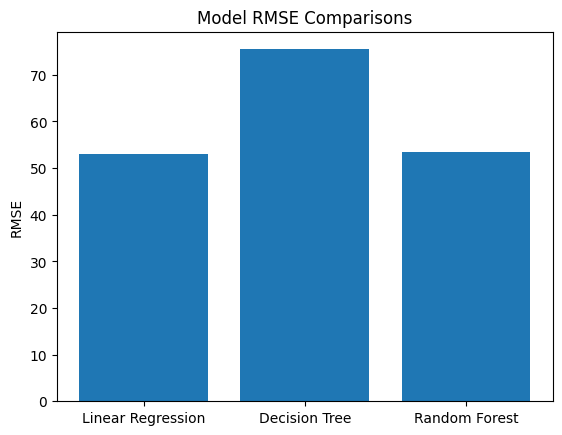

In [ ]:
# no siempre el mejor modelo es el mas adecuado para para los datos simples ya que tienede a memorizar y sus reultados salen probres

# Load the dataset
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  # Import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = load_diabetes()
X = data.data
y = data.target

# Split the data into training and test sets
# Assuming 'X' and 'y' are defined from previous code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a list of regression models
models = [
    ('Linear Regression', LinearRegression()),  # Instantiate LinearRegression
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))  # Instantiate RandomForestRegressor
]

rmse_scores = []

# Train each model and calculate RMSE
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append((name, rmse))
    print(f'{name} RMSE: {rmse:.2f}')

# Plotting
names, scores = zip(*rmse_scores)
plt.bar(names, scores)
plt.ylabel('RMSE')
plt.title('Model RMSE Comparisons')
plt.show()



Linear Regression R^2 Score: 0.48
Decision Tree R^2 Score: -0.06
Random Forest R^2 Score: 0.47


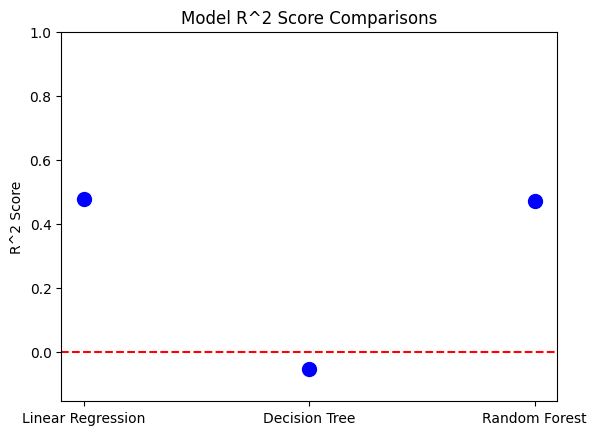

In [ ]:
# Load the dataset
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split  # Import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create a list of regression models
models = [
    ('Linear Regression', LinearRegression()),  # Instantiate LinearRegression
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),  # Instantiate DecisionTreeRegressor
    ('Random Forest', RandomForestRegressor(random_state=42))  # Instantiate RandomForestRegressor
]

r2_scores = []

# Train each model and calculate R^2 score
for name, model in models:
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    r2_scores.append((name, r2))
    print(f'{name} R^2 Score: {r2:.2f}')

# Plotting
names, scores = zip(*r2_scores)
plt.scatter(names, scores, color='blue', s=100)  # Scatter plot
plt.axhline(0, color='red', linestyle='--')  # Draw a horizontal line at R^2 = 0
plt.ylabel('R^2 Score')
plt.title('Model R^2 Score Comparisons')
plt.ylim(min(scores) - 0.1, 1)  # Setting the y-axis limits to be slightly below the minimum R^2 score and up to 1
plt.show()

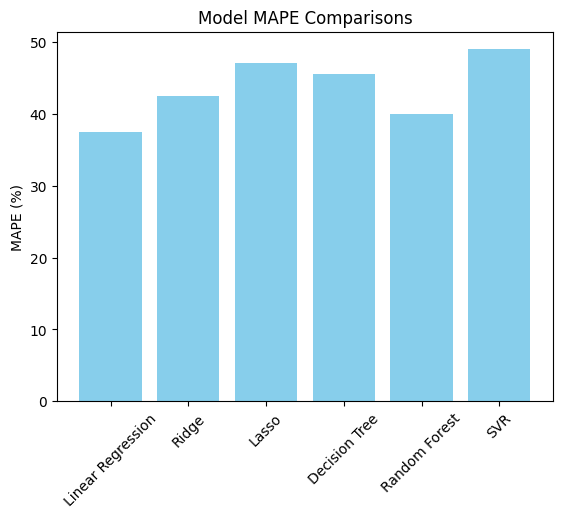

In [ ]:
# Load the diabetes dataset
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

from sklearn.model_selection import train_test_split  # Import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0  # Avoid division by zero
    return np.mean(
        np.abs(
            (y_true[non_zero_indices] - y_pred[non_zero_indices])
            / y_true[non_zero_indices]
        )
    ) * 100

# List of models to evaluate
models = [
    ('Linear Regression', LinearRegression()),  # Instantiate LinearRegression
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor()),  # Instantiate DecisionTreeRegressor
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())
]

mape_scores = []

# Train and evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, predictions)
    mape_scores.append((name, mape))

# Plotting
names, scores = zip(*mape_scores)
plt.bar(names, scores, color='skyblue')
plt.ylabel('MAPE (%)')
plt.title('Model MAPE Comparisons')
plt.xticks(rotation=45)
plt.show()

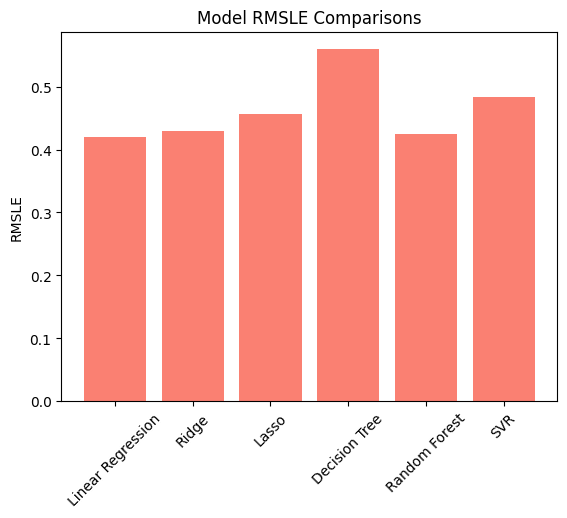

In [ ]:
# Import necessary libraries
from sklearn.metrics import mean_squared_log_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# Load the diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define RMSLE function
def root_mean_squared_log_error(y_true, y_pred):
    # Ensure predictions are positive (clip at a very small positive value)
    y_pred = np.clip(y_pred, 1e-10, np.inf)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# List of models to evaluate
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('SVR', SVR())  # Instantiate the SVR model
]

rmsle_scores = []

# Train and evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmsle = root_mean_squared_log_error(y_test, predictions)
    rmsle_scores.append((name, rmsle))

# Plotting
names, scores = zip(*rmsle_scores)
plt.bar(names, scores, color='salmon')
plt.ylabel('RMSLE')
plt.title('Model RMSLE Comparisons')
plt.xticks(rotation=45)
plt.show()